# Training Log Tracker

Parse BiaPy partitioned SLURM train `.out` logs into a DataFrame and plot metrics across partitions (`biapy_work_folder/biapy_train_track.py`).

In [14]:
import os
import sys
from pathlib import Path

root = Path.cwd()
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import pandas as pd

from biapy_work_folder.biapy_train_track import (
    consolidate_training_log,
    plot_training_across_partitions,
)

/scratch/wmz2007/neuroinfo_fruitfly


## Load training log

Point `LOG_PATH` at a SLURM train `.out` under `sbatch/biapy/`.

In [15]:
# Archeived
    # Partition
    # "sbatch/biapy/BiaPy-py-biapy-channel-rot-seunet-train-15784784.out"
    # "sbatch/biapy/BiaPy-py-biapy-channel-rot-seunet-train-15784784.out"
    # "sbatch/biapy/BiaPy-py-biapy-channel-scale-unetr-train-15747672.out"
    # "sbatch/biapy/BiaPy-py-biapy-channel-scale-seunet-train-15747668.out"

    # Run 0 weight (1, 10, 10, 1) / zarr cos
    # "sbatch/biapy/biapy-instance-scale-zarr-seunet-train-15979567.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-15975386.out"
    # "sbatch/biapy/biapy-channel-rot-zarr-unetr-train-15990905.out"

    # Run 0 weight (1, 5, 5, 1)
    # "sbatch/biapy/biapy-channel-scale-zarr-unetr-train-15990945.out"

    # Run 1 weight (1, 3, 3, 2) one cycle
    # "sbatch/biapy/biapy-channel-scale-zarr-unetr-train-16023896.out"

    # Channel-Scaling Run 0 
    # "sbatch/biapy/biapy-channel-scale-zarr-unetr-train-16044970.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-16076092.out"

    # Instance-Scaling Run 0 
    # "sbatch/biapy/biapy-instance-scale-zarr-unetr-train-16051569.out"
    # "sbatch/biapy/biapy-instance-scale-zarr-seunet-train-16076096.out"

    # Channel-Scaling Run 1 
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FP-train-16172365.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDc-train-16172361.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-16238457.out"


In [16]:
LOG_PATH = Path(
    # Double Channel
    # # F C
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FC-train-16238524.out"
    # # F D -- Failed
    # # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FD-train-16238426.out"
    # # F Db
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDb-train-16217312.out" #r0
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDb-train-16451089.out" #r1
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDb-r2-train-16465352.out" #r2
    # # F Dc
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDc-train-16172361.out"
    # # F Dn 
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDn-train-16211106.out"
    # # F P
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FP-train-16172365.out"

    # Multi Channel
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-16410919.out"

    # No-Aug Continual augmentation
    # F Db
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDb-r0-train-16907888.out"
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDb-r0-train-16959447.out"
    # F Dc Dn
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDcDn-r0-train-16909310.out"

    # Skel
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDb-skel-r0-train-17132187.out"

    # r1
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDb-skel-r1-train-17272017.out"
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDcDn-skel-r1-train-17272022.out"

    # adjust_v1
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDb-skel-radjust_v1-train-17301408.out"
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDcDn-skel-radjust_v1-train-17301414.out"

    # lr-cosine
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDb-skel-rlr_cosine-train-17344918.out"
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDcDn-skel-rlr_cosine-train-17343079.out"

    # no-patience
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDcDn-skel-rno-patience-train-17378206.out"

    # Dice
    # "sbatch/biapy/biapy-aug-zarr-seunet-FDb-dice-rbiapy_fdb_dice_l40s_wc_nopat_short_winner-train-17934425.out"
    # Skeleton
    "sbatch/biapy/biapy-aug-zarr-seunet-FDb-skel-rbiapy_fdb_skel_l40s_wc_nopat_short_winner-train-17934427.out"
)

df = consolidate_training_log(LOG_PATH)
print(
    f"{len(df)} epoch(s) across "
    f"{df['partition'].nunique() if not df.empty else 0} partition(s)"
)
# df = df[df['global_step'] >= 5]
# df = df[df['partition'] >= 0]
# df = df[df['partition'] != 0]
df.head()

240 epoch(s) across 1 partition(s)


,partition,epoch,global_step,train_loss,val_loss,train_iou_f,train_l1_db,val_iou_f,val_l1_db,lr,early_stopped
0,0,1,0,0.6828,0.4720,0.0106,0.1954,0.0214,0.0455,0.000279,False
1,0,2,1,0.4245,0.3795,0.0233,0.0260,0.0432,0.0164,0.000564,False
2,0,3,2,0.3455,0.3080,0.0341,0.0148,0.0693,0.0172,0.000849,False
3,0,4,3,0.2692,0.2360,0.0535,0.0148,0.0642,0.0123,0.000855,False
4,0,5,4,0.2034,0.1906,0.0692,0.0132,0.1320,0.0205,0.000855,False


In [17]:
df['epoch'].max(), df['train_loss'].min()

(240, -0.1992)

## Plot across partitions

X-axis is `global_step` (epochs concatenated across partitions). Dashed vertical lines mark partition boundaries.

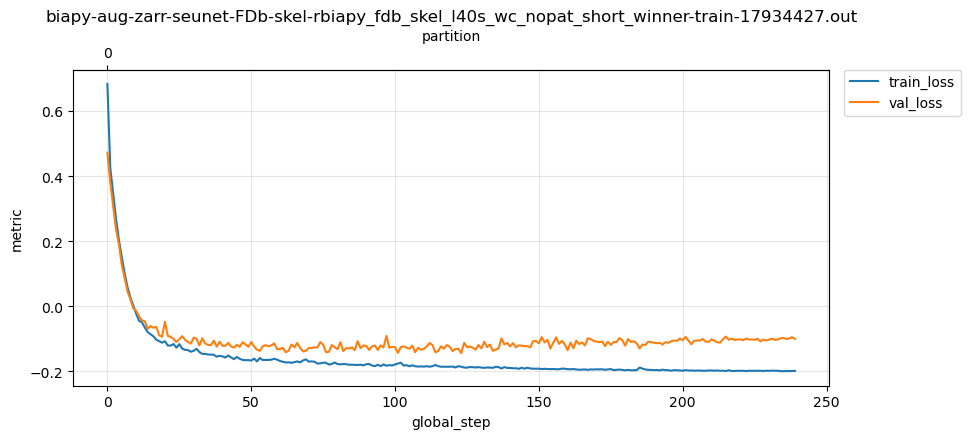

In [18]:
fig = plot_training_across_partitions(
    df,
    metrics=("train_loss", "val_loss"),
    # Avail metrics: train_iou_f,train_iou_c,train_l1_db,train_l1_dn,val_iou_f,val_iou_c,val_l1_db,val_l1_dn,lr,early_stopped
    title=LOG_PATH.name,
)
plt.show()

## Optional: other metrics

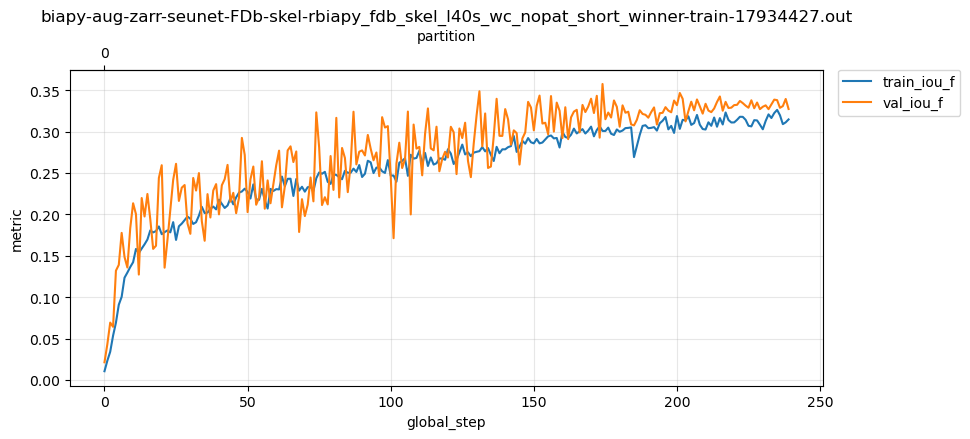

In [19]:
fig = plot_training_across_partitions(
    df,
    metrics=(
        "train_iou_f", "val_iou_f", 
        # "train_iou_p_channel", "val_iou_p_channel",
        # "train_iou_c", "val_iou_c"
        # "train_l1_dn", "val_l1_dn",
        # "train_l1_db", "val_l1_db"
        # "train_l1_dc_channel", "val_l1_dc_channel"
    ),
    title=f"{LOG_PATH.name}",
)
plt.show()

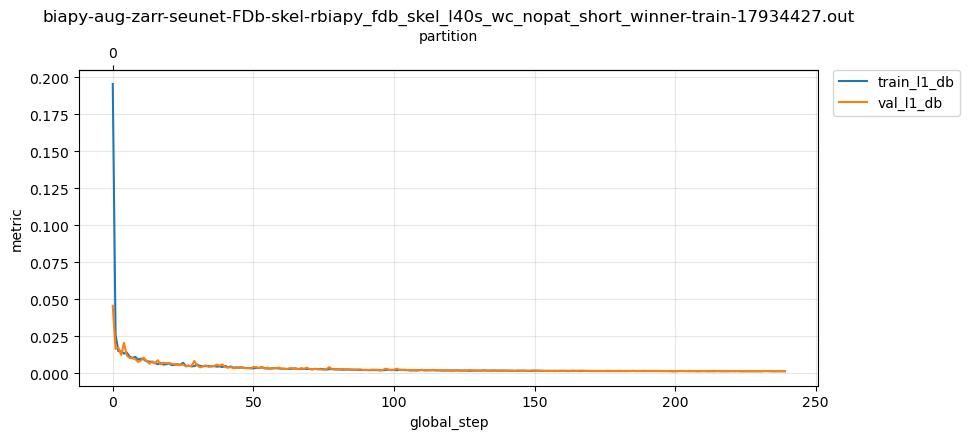

In [20]:
fig = plot_training_across_partitions(
    df,
    metrics=(
        # "train_iou_f", "val_iou_f", 
        # "train_iou_c", "val_iou_c"
        # "train_iou_p_channel", "val_iou_p_channel"
        "train_l1_db", "val_l1_db"
        # "train_l1_dn", "val_l1_dn",
        # "train_l1_dc_channel", "val_l1_dc_channel"
    ),
    title=f"{LOG_PATH.name}",
)
plt.show()

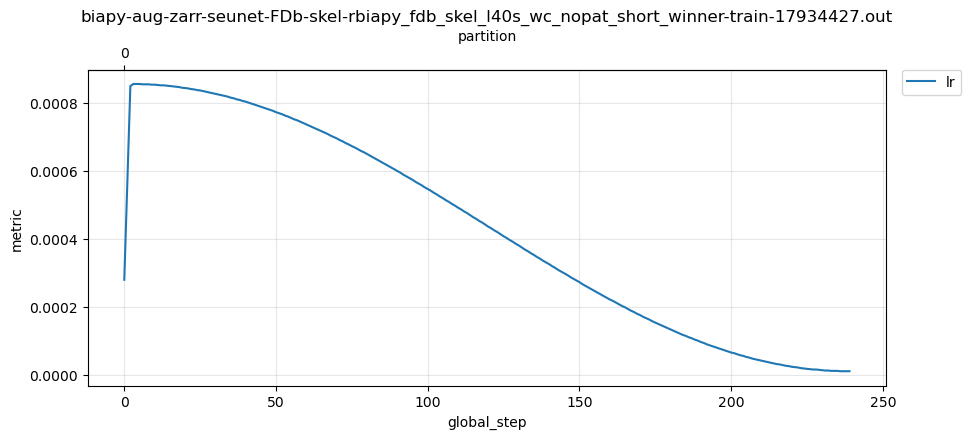

In [21]:
fig = plot_training_across_partitions(
    df,
    metrics=["lr"],
    title=f"{LOG_PATH.name}",
)
plt.show()